In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:/bhanu_projects/Ecommerce_Analytics_Project/data/online_retail.csv", encoding="latin1")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df.describe()

,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [6]:
df=df.dropna(subset=['Customer ID'])

In [7]:
df = df[~df['Invoice'].astype(str).str.contains('C')]

In [8]:
df=df[df['Quantity']>0]

In [9]:
df['Total_price']= df['Price']*df['Quantity']

In [10]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34


In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

In [12]:
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ','_')

In [13]:
df.columns


Index(['invoice', 'stockcode', 'description', 'quantity', 'invoicedate',
       'price', 'customer_id', 'country', 'total_price'],
      dtype='object')

In [14]:
df.to_csv("C:\\bhanu_projects\\Ecommerce_Analytics_Project\\data\\cleaned_data.csv", index=False)

In [15]:
pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\BUNNY YADAV\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [ ]:
from sqlalchemy import create_engine
username="postgres"
password = "your_password""
host="localhost"
port = "5432"
database = "ecommerce_db"

engine =create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")
table_name = "retail"
df.to_sql(table_name, engine, if_exists="replace", index=False)
print(f"Data successfully loaded into table '{table_name}' in databse '{database}'.")

Data successfully loaded into table 'retail' in databse 'ecommerce_db'.


In [ ]:
username="postgres"
password = "your_password""
host="localhost"
port = "5432"
database = "ecommerce_db"

engine =create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")
query ="select * from retail"
df=pd.read_sql(query, engine)
df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [18]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

snapshot_date = df['invoicedate'].max() + pd.Timedelta(days=1)

In [19]:
rfm = df.groupby('customer_id').agg({
    'invoicedate': lambda x: (snapshot_date - x.max()).days,
    'invoice': 'nunique',
    'total_price': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [20]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# Convert to int
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [21]:
def segment_customer(row):
    if row['RFM_score'] == '444':
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] == 1:
        return 'At Risk'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [22]:
rfm['Segment'].value_counts()

Segment
Regular            1732
At Risk            1084
Loyal Customers    1034
Champions           489
Name: count, dtype: int64

In [23]:
rfm.reset_index(inplace=True)

rfm.to_sql("rfm_table", engine, if_exists="replace", index=False)

print("RFM table uploaded to PostgreSQL successfully.")

RFM table uploaded to PostgreSQL successfully.


In [24]:
from sklearn.preprocessing import StandardScaler

rfm_kmeans = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_kmeans)

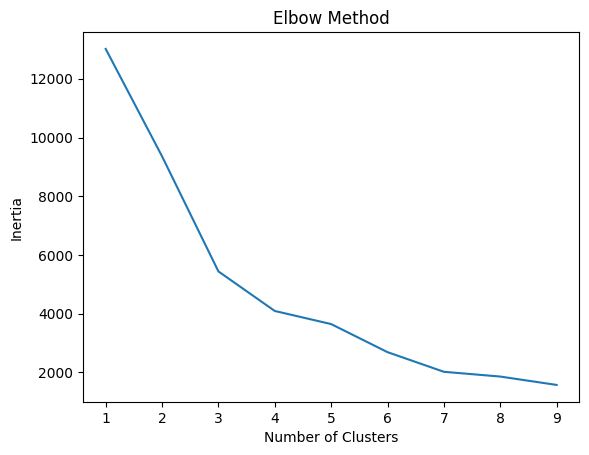

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [26]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment,Cluster
0,12346.0,326,1,77183.60,1,1,4,114,At Risk,0
1,12347.0,2,7,4310.00,4,4,4,444,Champions,3
2,12348.0,75,4,1797.24,2,3,4,234,Regular,3
3,12349.0,19,1,1757.55,3,1,4,314,Regular,3
4,12350.0,310,1,334.40,1,1,2,112,At Risk,1


In [27]:
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,15.672986,22.047393,12453.225924
1,248.564030,1.551789,478.107581
2,7.384615,82.692308,127338.313846
3,43.910580,3.655748,1349.704194


In [28]:
cluster_mapping = {
    0: "Loyal Customers",
    1: "Churned / Inactive",
    2: "VIP Customers",
    3: "Regular Customers"
}

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_mapping)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment,Cluster,Cluster_Label
0,12346.0,326,1,77183.60,1,1,4,114,At Risk,0,Loyal Customers
1,12347.0,2,7,4310.00,4,4,4,444,Champions,3,Regular Customers
2,12348.0,75,4,1797.24,2,3,4,234,Regular,3,Regular Customers
3,12349.0,19,1,1757.55,3,1,4,314,Regular,3,Regular Customers
4,12350.0,310,1,334.40,1,1,2,112,At Risk,1,Churned / Inactive


In [29]:
rfm.reset_index(inplace=True)

rfm.to_sql("customer_segmentation", engine, if_exists="replace", index=False)

print("Updated segmentation table uploaded.")

Updated segmentation table uploaded.


In [30]:
rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)

In [31]:
rfm['Churn'].value_counts()

Churn
0    2890
1    1449
Name: count, dtype: int64

In [32]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important for balanced split
)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9896313364055299

Confusion Matrix:
 [[578   0]
 [  9 281]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       578
           1       1.00      0.97      0.98       290

    accuracy                           0.99       868
   macro avg       0.99      0.98      0.99       868
weighted avg       0.99      0.99      0.99       868



In [37]:
rfm['Churn_Probability'] = model.predict_proba(
    scaler.transform(X)
)[:,1]

In [38]:
rfm[['Recency','Churn','Churn_Probability']].head()

,Recency,Churn,Churn_Probability
0,326,1,1.000000
1,2,0,0.000026
2,75,0,0.103254
3,19,0,0.000176
4,310,1,1.000000


In [39]:
rfm.reset_index(inplace=True)

rfm.to_sql("customer_churn_model", engine, if_exists="replace", index=False)

print("Churn model uploaded successfully.")

Churn model uploaded successfully.
